In [ ]:
#=============================================================#
#                         Instalações                         #
#=============================================================#
!pip install numpy pandas matplotlib scipy

In [ ]:
#=============================================================#
#            IMPORTAÇÕES + CONFIGURAÇÕES GERAIS               #
#=============================================================#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from math import sqrt, pi

plt.rcParams['figure.dpi'] = 110

MAX_HARMONIC = 25   # até 25ª ordem
WINDOW_CYCLES = 1
VERBOSE = False

In [ ]:
#=============================================================#
#                   FUNÇÕES UTILITÁRIAS                       #
#=============================================================#
def pretty_card(title, lines, width=60):
    print("="*width)
    print(f"{title.center(width)}")
    print("-"*width)
    for key, val in lines:
        print(f"{key:<28} {val:>30}")
    print("="*width + "\n")

def safe_mean(xs):
    return np.mean(xs) if len(xs)>0 else 0.0


In [ ]:
#=============================================================#
#                  FUNÇÕES DE CARREGAMENTO                    #
#=============================================================#
def carregar_de_arquivo(path, delim_whitespace=True):
    if delim_whitespace:
        data = np.loadtxt(path)
    else:
        data = np.genfromtxt(path, delimiter=',')
    t = data[:,0]
    Va = data[:,1]
    Ia = data[:,2]
    return t, Va, Ia

def carregar_de_dataframe(df):
    t = df.iloc[:,0].values
    Va = df.iloc[:,1].values
    Ia = df.iloc[:,2].values
    return t, Va, Ia

In [ ]:
#=============================================================#
#         EXTRAÇÃO DE CICLO + DETECÇÃO DE FUNDAMENTAL         #
#=============================================================#
def extrair_um_ciclo_matlabstyle(t, x, f1=60.0):



    N = len(x)
    idx0 = None
    for k in range(N - 1):
        if x[k] == 0 or x[k] * x[k + 1] < 0:
            idx0 = k
            break

    if idx0 is None:
        raise ValueError("Nenhum cruzamento por zero encontrado.")

    # PASSO 2: Calcular N1 ao estilo MATLAB
    Ts = t[1] - t[0]
    fs = 1.0 / Ts
    N1 = int(round(fs / f1))

    # PASSO 3: Recortar 1 ciclo
    if idx0 + N1 < N:
        t_ciclo = t[idx0 : idx0 + N1]
        x_ciclo = x[idx0 : idx0 + N1]
    else:
        t_ciclo = t[idx0:]
        x_ciclo = x[idx0:]

    # PASSO 4: Ajustar início do tempo
    t_ciclo = t_ciclo - t_ciclo[0]

    return t_ciclo, x_ciclo, f1


In [ ]:
#=============================================================#
#                 FFT + EXTRAÇÃO HARMÔNICA                    #
#=============================================================#
def harmonicas_via_fft_matlabstyle(x, fs, f0, max_h=25):

    import math
    N = len(x)
    if N == 0:
        raise ValueError("Sinal vazio")

    X = fft(x)            # FFT complexa
    freqs = fftfreq(N, 1.0/fs)
    X_div_N = X / N

    h_rms = np.zeros(max_h + 1, dtype=float)

    # DC (h=0)
    h_rms[0] = np.abs(X_div_N[0])


    for h in range(1, max_h + 1):
        idx = int(round(h * f0 * N / fs))

        if 0 <= idx < len(X_div_N):
            complex_h = X_div_N[idx]
            h_rms[h] = np.abs(complex_h) * math.sqrt(2)
        else:
            h_rms[h] = 0.0

    return h_rms, freqs, X_div_N


In [ ]:
#=============================================================#
#       INDICADORES HARMÔNICOS (THD, DHTE, DTT, DHI)          #
#=============================================================#
def DHI_percent(h_rms, h):
    """
    Distorção Harmônica Individual (Vh / V1 * 100)
    h_rms = array onde índice é a ordem h.
    """
    if h == 0:
        return 0.0
    V1 = h_rms[1]
    return 100 * h_rms[h] / V1 if V1 != 0 else np.nan


def THD_IEEE519_percent(h_rms):
    """
    THD segundo IEEE 519:
    THD = sqrt(sum(Vh², h>=2)) / V1 * 100
    """
    V1 = h_rms[1]
    if V1 == 0:
        return np.nan
    return 100 * np.sqrt(np.sum(h_rms[2:]**2)) / V1


def THD_IEEE1459_percent(h_rms):
    """
    THD segundo IEEE 1459 (corrigido):
    THD = sqrt(Vrms² - V1²) / V1 * 100
    """
    V1 = h_rms[1]
    Vrms_total = np.sqrt(np.sum(h_rms**2))
    if V1 == 0:
        return np.nan
    return 100 * np.sqrt(max(Vrms_total**2 - V1**2, 0.0)) / V1


def DHTE_percent(h_rms):
    """
    DHTE TOTAL (como o professor exige):
    DHTE = sqrt(sum(Vh², h>=2)) / Vrms_total * 100
    """
    Vr_h = np.sqrt(np.sum(h_rms[2:]**2))
    Vrms_total = np.sqrt(np.sum(h_rms**2))
    if Vrms_total == 0:
        return np.nan
    return 100 * Vr_h / Vrms_total


def DTT_PRODIST_percent(h_rms):
    """
    DTT conforme PRODIST:
    - DTT  = contribuição total das harmônicas
    - DTTp = pares (exceto múltiplas de 3)
    - DTTi = ímpares (exceto múltiplas de 3)
    - DTT3 = múltiplas de 3
    """
    Vrms_total = np.sqrt(np.sum(h_rms**2))
    if Vrms_total == 0:
        return (np.nan, np.nan, np.nan, np.nan)

    even_non3 = []
    odd_non3 = []
    mult3 = []

    for h in range(2, len(h_rms)):
        if h % 3 == 0:
            mult3.append(h_rms[h]**2)
        else:
            if h % 2 == 0:
                even_non3.append(h_rms[h]**2)
            else:
                odd_non3.append(h_rms[h]**2)

    DTT  = 100 * np.sqrt(np.sum(even_non3 + odd_non3 + mult3)) / Vrms_total
    DTTp = 100 * np.sqrt(np.sum(even_non3)) / Vrms_total
    DTTi = 100 * np.sqrt(np.sum(odd_non3)) / Vrms_total
    DTT3 = 100 * np.sqrt(np.sum(mult3)) / Vrms_total

    return DTT, DTTp, DTTi, DTT3

In [ ]:
#=============================================================#
#                   POTÊNCIAS IEEE 1459                       #
#=============================================================#
def potencias_1459(t_cycle, v_cycle, i_cycle):
    Ts = t_cycle[1] - t_cycle[0]
    fs = 1 / Ts
    N = len(v_cycle)

    Vrms = np.sqrt(np.mean(v_cycle**2))
    Irms = np.sqrt(np.mean(i_cycle**2))

    P_total = np.mean(v_cycle * i_cycle)
    S_total = Vrms * Irms

    Xv = fft(v_cycle) / N
    Xi = fft(i_cycle) / N
    freqs = fftfreq(N, 1/fs)

    f0 = detectar_fundamental_por_fft(v_cycle, fs)
    idx = np.argmin(np.abs(freqs - f0))

    V1 = np.sqrt(2) * np.abs(Xv[idx])
    I1 = np.sqrt(2) * np.abs(Xi[idx])

    ang_v = np.angle(Xv[idx])
    ang_i = np.angle(Xi[idx])

    phi = ang_v - ang_i

    P1 = V1 * I1 * np.cos(phi)
    Q1 = V1 * I1 * np.sin(phi)
    S1 = V1 * I1

    FP1 = np.cos(phi)
    FP_true = P_total / S_total

    return {
        "Vrms": Vrms, "Irms": Irms,
        "P_total": P_total, "S_total": S_total,
        "P1": P1, "Q1": Q1, "S1": S1,
        "FP1": FP1, "FP_true": FP_true,
        "phi": phi
    }


In [ ]:
#=============================================================#
#                FATOR K, FHL e DESCLASSIFICAÇÃO              #
#=============================================================#

def calcular_fatorK_e_FHL(hI_rms):
    H = np.arange(len(hI_rms))
    I1 = hI_rms[1]
    I_total = np.sqrt(np.sum(hI_rms**2))

    # ----- FATOR K  -----
    FatorK = np.sum((H**2) * (hI_rms / I1)**2)

    # ----- FHL  -----
    num = np.sum((H**2) * (hI_rms / I_total)**2)
    den = np.sum((hI_rms / I_total)**2)
    FHL = num / den if den != 0 else np.nan

    return FatorK, FHL


#=============================================================#
#                DESCLASSIFICAÇÃO CBEMA (CORRIGIDA)           #
#=============================================================#

def desclassificacao_trafo_CBEMA(Irms_true, Ip_peak):
    FC = Ip_peak / Irms_true
    KFC = (np.sqrt(2) * Irms_true) / Ip_peak
    return {"FC": FC, "KFC": KFC}


#=============================================================#
#           DESCLASSIFICAÇÃO IEEE C57 OIL (PERMANECE)         #
#=============================================================#

def desclassificacao_trafo_C57_oil(Irms_true, I_nom, FHL):
    return {"Imax_on_Inom": 1.15 / (1 + 0.15 * FHL)}

#=============================================================#
#       DESCLASSIFICAÇÃO IEEE C57 OIL (CORRIGIDO, KFCO)       #
#=============================================================#

def desclassificacao_trafo_C57_oil(Irms_true, I_nom, FHL):
    """
    Slide:
    Imax / Inom = KFCO = 1.15 / (1 + 0.15*FHL)
    """
    KFCO = 1.15 / (1 + 0.15 * FHL)
    return {"KFCO": KFCO}


In [ ]:
# ================================================================#
# ETAPA 10 — PIPELINE COMPLETO (VERSÃO BONITA + EMOJIS + GRÁFICOS)#
# ================================================================#

def emoji_card(title, items, width=72):
    """Card estilizado com emojis."""
    border = "━" * width
    print(f"\n💠 {border}")
    print(f"⚡ {title.upper():^{width}}")
    print(f"💠 {border}")
    for label, value in items:
        print(f"➤ {label:<35} ➜  {value}")
    print(f"💠 {border}\n")

def analisar_pipeline(t, Va, Ia, plot=True, show_tables=True):
    print("\n\n📊✨ **INICIANDO ANÁLISE COMPLETA DO SINAL** ✨📊\n")


#=============================================================#
#                    ETAPA A: Sinal completo                  #
#=============================================================#

    Ts = t[1] - t[0]
    fs = 1/Ts
    N = len(t)

    if plot:
        plt.figure(figsize=(12,5))
        plt.subplot(2,1,1)
        plt.plot(t, Va, label="Tensão", color='blue')
        plt.title("📌 Etapa 1 — Sinal Completo (Tensão)")
        plt.grid(True)

        plt.subplot(2,1,2)
        plt.plot(t, Ia, label="Corrente", color='red')
        plt.title("📌 Etapa 1 — Sinal Completo (Corrente)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    emoji_card("Etapa 1 – Informações do sinal", [
        ("📏 Amostras", f"{N}"),
        ("⏱️ Período de amostragem Ts", f"{Ts:.6e} s"),
        ("🎚️ Frequência de amostragem", f"{fs:.2f} Hz"),
    ])

  #=============================================================#
  #                ETAPA B: Extração de um ciclo                #
  #=============================================================#
    tV, Vc, f0V = extrair_um_ciclo_matlabstyle(t, Va, f1=60.0)
    tI, Ic, f0I = extrair_um_ciclo_matlabstyle(t, Ia, f1=60.0)


    f0 = (f0V + f0I) / 2

    samples_cycle = len(tV)

    if plot:
        plt.figure(figsize=(12,4))
        plt.plot(tV, Vc, 'b.-')
        plt.plot(tI, Ic, 'r.-')
        plt.title("📌 Etapa 2 — Ciclo Extraído (Tensão e Corrente)")
        plt.grid(True)
        plt.show()

    emoji_card("Etapa 2 – Ciclo extraído", [
        ("🎵 Frequência fundamental estimada", f"{f0:.4f} Hz"),
        ("🔁 Período fundamental", f"{1/f0:.6f} s"),
        ("📊 Amostras no ciclo", f"{samples_cycle}"),
    ])
#=============================================================#
#                  ETAPA C: FFT + Harmônicas                  #
#=============================================================#
    hV, freqsV, Xv = harmonicas_via_fft_matlabstyle(Vc, fs, f0)
    hI, freqsI, Xi = harmonicas_via_fft_matlabstyle(Ic, fs, f0)


    df_h = pd.DataFrame({
        "Harmônica h": np.arange(MAX_HARMONIC+1),
        "Vrms (h)": np.round(hV,5),
        "Irms (h)": np.round(hI,5),
    })

    if plot:
        plt.figure(figsize=(12,5))
        plt.bar(range(MAX_HARMONIC+1), hV, color="royalblue")
        plt.title("📌 Etapa 3 — Espectro Harmônico de Tensão (0–25)")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(12,5))
        plt.bar(range(MAX_HARMONIC+1), hI, color="firebrick")
        plt.title("📌 Espectro Harmônico de Corrente (0–25)")
        plt.grid(True)
        plt.show()

    if show_tables:
        print("\n📘 **Tabela de Harmônicas (0–25)**")
        display(df_h)

#=============================================================#
#               ETAPA D: THD, DHTE, DTT, DHI                  #
#=============================================================#
    Vrms = np.sqrt(np.sum(hV**2))
    Irms = np.sqrt(np.sum(hI**2))
    V1 = hV[1]
    I1 = hI[1]

    THDV_519 = THD_IEEE519_percent(hV)
    THDI_519 = THD_IEEE519_percent(hI)
    THDV_1459 = THD_IEEE1459_percent(hV)
    THDI_1459 = THD_IEEE1459_percent(hI)
    DHTE_V = DHTE_percent(hV)
    DHTE_I = DHTE_percent(hI)
    DTT_V, DTTp_V, DTTi_V, DTT3_V = DTT_PRODIST_percent(hV)
    DTT_I, DTTp_I, DTTi_I, DTT3_I = DTT_PRODIST_percent(hI)

    emoji_card("Tensão e Corrente Fundamental e Verdadeira", [
        ("🔵 Vrms (True)", f"{Vrms:.4f} V"),
        ("🔵 Vrms1 (fundamental)", f"{V1:.4f} V"),
        ("🔴 Irms (True)", f"{Irms:.4f} A"),
        ("🔴 Irms1 (fundamental)", f"{I1:.4f} A"),
    ])
    emoji_card("Distorções Harmônicas de Tensão", [
        ("📉 DHTV (IEEE 519)", f"{THDV_519:.3f} %"),
        ("📐 DHTV (IEEE 1459)", f"{THDV_1459:.3f} %"),
        ("📊 DHTE (Tensão)", f"{DHTE_V:.3f} %"),
        ("🔹 DTTV  (PRODIST)", f"{DTT_V:.3f} %"),
        ("▫ DTTVP (pares)", f"{DTTp_V:.3f} %"),
        ("▫ DTTVI (ímpares)", f"{DTTi_V:.3f} %"),
        ("▫ DTTV3 (3ª ordem)", f"{DTT3_V:.3f} %"),
    ])

    emoji_card("Distorções Harmônicas de Corrente", [
        ("📉 DHTI (IEEE 519)", f"{THDI_519:.3f} %"),
        ("📐 DHTI (IEEE 1459)", f"{THDI_1459:.3f} %"),
        ("📊 DHTE (Corrente)", f"{DHTE_I:.3f} %"),
        ("🔹 DTTI  (PRODIST)", f"{DTT_I:.3f} %"),
        ("▫ DTTIP (pares)", f"{DTTp_I:.3f} %"),
        ("▫ DTTII (ímpares)", f"{DTTi_I:.3f} %"),
        ("▫ DTTI3 (3ª ordem)", f"{DTT3_I:.3f} %"),
    ])


#=============================================================#
#              ETAPA E: Potências (IEEE 1459)                 #
#=============================================================#

    # -----------------------------
    # ETAPA 5: Potências (IEEE 1459)
    # -----------------------------
    pot = potencias_1459(tV, Vc, Ic, detectar_fundamental_por_fft)
    FPV = pot["FP_true"]       # FP verdadeiro
    FD  = I1 / Irms            # fator de distorção clássico

    pot["FPV"] = FPV
    pot["FD"]  = FD

    emoji_card("Etapa 5 – Potências IEEE 1459", [
        ("⚡ P total (W)", f"{pot['P_total']:.3f}"),
        ("🔌 S total (VA)", f"{pot['S_total']:.3f}"),
        ("➤ P1 (W)", f"{pot['P1']:.3f}"),
        ("➤ Q1 (VAR)", f"{pot['Q1']:.3f}"),
        ("➤ S1 (VA)", f"{pot['S1']:.3f}"),
        ("📐 FP1", f"{pot['FP1']:.4f}"),
        ("📐 FP verdadeiro", f"{pot['FP_true']:.4f}"),
        ("🎛️ Ângulo φ", f"{pot['phi']:.4f} rad"),
        ("🎚️ FD (Fator de Distorção)", f"{pot['FD']:.4f}"),
    ])

    #=============================================================#
    #           ETAPA F: Fator K, FHL e desclassificação          #
    #=============================================================#
    K, FHL = calcular_fatorK_e_FHL(hI)
    Ip_peak = np.max(np.abs(Ic))

    # Desclassificação CBEMA
    cbema = desclassificacao_trafo_CBEMA(Irms, Ip_peak)

    # Desclassificação C57 – KFCO
    dic_c57 = desclassificacao_trafo_C57_oil(Irms, 1.0, FHL)  # Inom = 1 p.u.
    KFCO = dic_c57["KFCO"]

    emoji_card("Etapa 6 – Fator K / FHL / Desclassificação", [
        ("🧲 Fator K (ANSI/IEEE)", f"{K:.4f}"),
        ("🧮 FHL (Harmônicos)", f"{FHL:.4f}"),
        ("📈 Ipico", f"{Ip_peak:.4f} A"),
        ("📉 KFC (CBEMA)", f"{cbema['KFC']:.4f}"),
        ("🏭 KFCO (C57 - Imax/Inom)", f"{KFCO:.4f}"),
    ])

    print("\n\n🎉✨ **ANÁLISE FINALIZADA COM SUCESSO!** ✨🎉\n")

    # RETORNO FINAL (deve estar INDENTADO dentro da função)
    return {
        "harmonics": df_h,

        "t": t,
        "Va": Va,
        "Ia": Ia,
        "Vrms": Vrms,
        "V1": V1,
        "Irms": Irms,
        "I1": I1,

        "THD519V": THDV_519,
        "THD519I": THDI_519,

        "THD1459V": THDV_1459,
        "THD1459I": THDI_1459,

        "DHTE_V": DHTE_V,
        "DHTE_I": DHTE_I,

        "DTT_V": DTT_V,
        "DTT_VP": DTTp_V,
        "DTT_VI": DTTi_V,
        "DTT_V3": DTT3_V,

        "DTT_I": DTT_I,
        "DTT_IP": DTTp_I,
        "DTT_II": DTTi_I,
        "DTT_I3": DTT3_I,

        "pot": pot,

        "FatorK": K,
        "FHL": FHL,
        "KFC": cbema["KFC"],
        "KFCO": KFCO
    }

In [ ]:
def detectar_fundamental_por_fft(x, fs):
    """
    Detecta a frequência fundamental usando FFT, ignorando o DC.
    """
    N = len(x)
    X = np.fft.fft(x)
    freqs = np.fft.fftfreq(N, 1/fs)

    # Ignorar componentes negativas
    idx_pos = np.where(freqs > 0)
    freqs_pos = freqs[idx_pos]
    X_pos = np.abs(X[idx_pos])

    # Identifica o pico (fundamental)
    fundamental_freq = freqs_pos[np.argmax(X_pos)]

    return fundamental_freq

In [ ]:
# ================================================================#
# ETAPA 10 — PIPELINE COMPLETO (VERSÃO BONITA + EMOJIS + GRÁFICOS)
# ================================================================#

def emoji_card(title, items, width=72):
    """Card estilizado com emojis."""
    border = "━" * width
    print(f"\n💠 {border}")
    print(f"⚡ {title.upper():^{width}}")
    print(f"💠 {border}")
    for label, value in items:
        print(f"➤ {label:<35} ➜  {value}")
    print(f"💠 {border}\n")


def analisar_pipeline(t, Va, Ia, plot=True, show_tables=True):

    print("\n\n📊✨ **INICIANDO ANÁLISE COMPLETA DO SINAL** ✨📊\n")

    #=============================================================#
    #                    ETAPA A: Sinal completo                  #
    #=============================================================#

    Ts = t[1] - t[0]
    fs = 1 / Ts
    N = len(t)

    if plot:
        plt.figure(figsize=(12,5))

        plt.subplot(2,1,1)
        plt.plot(t, Va, label="Tensão", color='blue')
        plt.title("📌 Etapa 1 — Sinal Completo (Tensão)")
        plt.grid(True)

        plt.subplot(2,1,2)
        plt.plot(t, Ia, label="Corrente", color='red')
        plt.title("📌 Etapa 1 — Sinal Completo (Corrente)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    emoji_card("Etapa 1 – Informações do sinal", [
        ("📏 Amostras", f"{N}"),
        ("⏱️ Ts", f"{Ts:.6e} s"),
        ("🎚️ Frequência de amostragem", f"{fs:.2f} Hz"),
    ])

    #=============================================================#
    #                ETAPA B: Extração de um ciclo                #
    #=============================================================#

    tV, Vc, f0V = extrair_um_ciclo_matlabstyle(t, Va, f1=60.0)
    tI, Ic, f0I = extrair_um_ciclo_matlabstyle(t, Ia, f1=60.0)

    f0 = (f0V + f0I) / 2
    samples_cycle = len(tV)

    if plot:
        plt.figure(figsize=(12,4))
        plt.plot(tV, Vc, 'b.-')
        plt.plot(tI, Ic, 'r.-')
        plt.title("📌 Etapa 2 — Ciclo Extraído (Tensão e Corrente)")
        plt.grid(True)
        plt.show()

    emoji_card("Etapa 2 – Ciclo extraído", [
        ("🎵 Frequência fundamental estimada", f"{f0:.4f} Hz"),
        ("🔁 Período fundamental", f"{1/f0:.6f} s"),
        ("📊 Amostras no ciclo", f"{samples_cycle}"),
    ])

    #=============================================================#
    #                  ETAPA C: FFT + Harmônicas                  #
    #=============================================================#

    hV, freqsV, Xv = harmonicas_via_fft_matlabstyle(Vc, fs, f0)
    hI, freqsI, Xi = harmonicas_via_fft_matlabstyle(Ic, fs, f0)

    df_h = pd.DataFrame({
        "Harmônica h": np.arange(MAX_HARMONIC+1),
        "Vrms (h)": np.round(hV,5),
        "Irms (h)": np.round(hI,5),
    })

    if plot:
        plt.figure(figsize=(12,5))
        plt.bar(range(MAX_HARMONIC+1), hV, color="royalblue")
        plt.title("📌 Etapa 3 — Espectro Harmônico de Tensão (0–25)")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(12,5))
        plt.bar(range(MAX_HARMONIC+1), hI, color="firebrick")
        plt.title("📌 Espectro Harmônico de Corrente (0–25)")
        plt.grid(True)
        plt.show()

    if show_tables:
        print("\n📘 **Tabela de Harmônicas (0–25)**")
        display(df_h)

    #=============================================================#
    #               ETAPA D: THD, DHTE, DTT, DHI                  #
    #=============================================================#

    Vrms = np.sqrt(np.sum(hV**2))
    Irms = np.sqrt(np.sum(hI**2))
    V1 = hV[1]
    I1 = hI[1]

    THDV_519 = THD_IEEE519_percent(hV)
    THDI_519 = THD_IEEE519_percent(hI)
    THDV_1459 = THD_IEEE1459_percent(hV)
    THDI_1459 = THD_IEEE1459_percent(hI)
    DHTE_V = DHTE_percent(hV)
    DHTE_I = DHTE_percent(hI)
    DTT_V, DTTp_V, DTTi_V, DTT3_V = DTT_PRODIST_percent(hV)
    DTT_I, DTTp_I, DTTi_I, DTT3_I = DTT_PRODIST_percent(hI)

    emoji_card("Tensão e Corrente Fundamental e Verdadeira", [
        ("🔵 Vrms (True)", f"{Vrms:.4f} V"),
        ("🔵 V1", f"{V1:.4f} V"),
        ("🔴 Irms (True)", f"{Irms:.4f} A"),
        ("🔴 I1", f"{I1:.4f} A"),
    ])

    emoji_card("Distorções Harmônicas de Tensão", [
        ("📉 DHTV (IEEE 519)", f"{THDV_519:.3f} %"),
        ("📐 DHTV (IEEE 1459)", f"{THDV_1459:.3f} %"),
        ("📊 DHTE (Tensão)", f"{DHTE_V:.3f} %"),
        ("▫ DTTV  (PRODIST)", f"{DTT_V:.3f} %"),
        ("▫ DTTVP (pares)", f"{DTTp_V:.3f} %"),
        ("▫ DTTVI (ímpares)", f"{DTTi_V:.3f} %"),
        ("▫ DTTV3 (3ª ordem)", f"{DTT3_V:.3f} %"),
    ])

    emoji_card("Distorções Harmônicas de Corrente", [
        ("📉 DHTI (IEEE 519)", f"{THDI_519:.3f} %"),
        ("📐 DHTI (IEEE 1459)", f"{THDI_1459:.3f} %"),
        ("📊 DHTE (Corrente)", f"{DHTE_I:.3f} %"),
        ("▫ DTTI  (PRODIST)", f"{DTT_I:.3f} %"),
        ("▫ DTTIP (pares)", f"{DTTp_I:.3f} %"),
        ("▫ DTTII (ímpares)", f"{DTTi_I:.3f} %"),
        ("▫ DTTI3 (3ª ordem)", f"{DTT3_I:.3f} %"),
    ])

    #=============================================================#
    #              ETAPA E: Potências (IEEE 1459)                 #
    #=============================================================#

    pot = potencias_1459(tV, Vc, Ic)   # <<< CORREÇÃO AQUI

    FPV = pot["FP_true"]
    FD  = I1 / Irms

    pot["FPV"] = FPV
    pot["FD"]  = FD

    emoji_card("Etapa 5 – Potências IEEE 1459", [
        ("⚡ P total (W)", f"{pot['P_total']:.3f}"),
        ("🔌 S total (VA)", f"{pot['S_total']:.3f}"),
        ("➤ P1 (W)", f"{pot['P1']:.3f}"),
        ("➤ Q1 (VAR)", f"{pot['Q1']:.3f}"),
        ("➤ S1 (VA)", f"{pot['S1']:.3f}"),
        ("📐 FP1", f"{pot['FP1']:.4f}"),
        ("📐 FP verdadeiro", f"{pot['FP_true']:.4f}"),
        ("🎛️ Ângulo φ", f"{pot['phi']:.4f} rad"),
        ("🎚️ FD (Fator de Distorção)", f"{pot['FD']:.4f}"),
    ])

    #=============================================================#
    #           ETAPA F: Fator K, FHL e desclassificação          #
    #=============================================================#

    K, FHL = calcular_fatorK_e_FHL(hI)
    Ip_peak = np.max(np.abs(Ic))

    cbema = desclassificacao_trafo_CBEMA(Irms, Ip_peak)
    dic_c57 = desclassificacao_trafo_C57_oil(Irms, 1.0, FHL)
    KFCO = dic_c57["KFCO"]

    emoji_card("Etapa 6 – Fator K / FHL / Desclassificação", [
        ("🧲 Fator K (ANSI/IEEE)", f"{K:.4f}"),
        ("🧮 FHL (Harmônicos)", f"{FHL:.4f}"),
        ("📈 Ipico", f"{Ip_peak:.4f} A"),
        ("📉 KFC (CBEMA)", f"{cbema['KFC']:.4f}"),
        ("🏭 KFCO (C57 - Imax/Inom)", f"{KFCO:.4f}"),
    ])

    print("\n\n🎉✨ **ANÁLISE FINALIZADA COM SUCESSO!** ✨🎉\n")

    #=============================================================#
    #                     RETORNO FINAL                           #
    #=============================================================#
    return {
        "harmonics": df_h,
        "t": t, "Va": Va, "Ia": Ia,
        "Vrms": Vrms, "V1": V1,
        "Irms": Irms, "I1": I1,
        "THD519V": THDV_519, "THD519I": THDI_519,
        "THD1459V": THDV_1459, "THD1459I": THDI_1459,
        "DHTE_V": DHTE_V, "DHTE_I": DHTE_I,
        "DTT_V": DTT_V, "DTT_VP": DTTp_V,
        "DTT_VI": DTTi_V, "DTT_V3": DTT3_V,
        "DTT_I": DTT_I, "DTT_IP": DTTp_I,
        "DTT_II": DTTi_I, "DTT_I3": DTT3_I,
        "pot": pot,
        "FatorK": K, "FHL": FHL,
        "KFC": cbema["KFC"],
        "KFCO": KFCO
    }


In [ ]:
t, Va, Ia = carregar_de_arquivo('/content/a6.txt')

print("Primeiros valores de t:", t[:5])
print("Primeiros valores de Va:", Va[:5])
print("Primeiros valores de Ia:", Ia[:5])


Primeiros valores de t: [0.000e+00 3.255e-05 6.510e-05 9.765e-05 1.302e-04]
Primeiros valores de Va: [ 223.198 -232.919  684.481 -222.297  685.199]
Primeiros valores de Ia: [2315.53 2285.2  2349.18 2413.88 2477.57]


In [ ]:
!ls -lh /content

total 228K
-rw-r--r-- 1 root root  47K Dec  1 11:05 6.txt
-rw-r--r-- 1 root root  87K Dec  1 11:07 a6.txt
-rw-r--r-- 1 root root  87K Dec  1 11:06 a8.txt
drwxr-xr-x 1 root root 4.0K Nov 20 14:30 sample_data




📊✨ **INICIANDO ANÁLISE COMPLETA DO SINAL** ✨📊



/tmp/ipython-input-1461967397.py:40: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


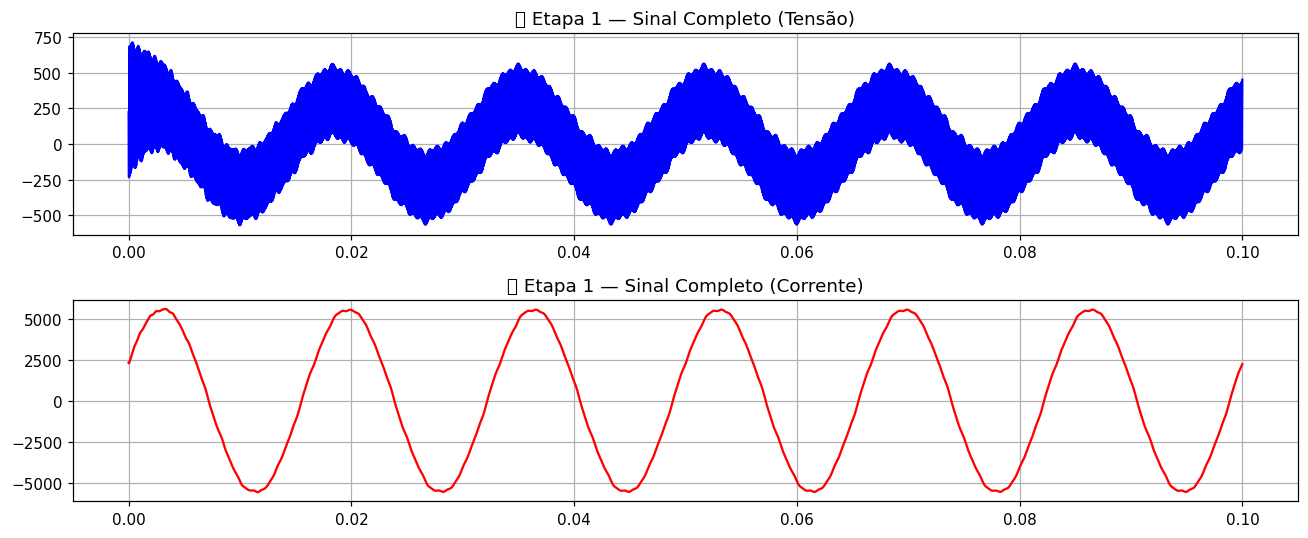


💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                      ETAPA 1 – INFORMAÇÕES DO SINAL                     
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ 📏 Amostras                          ➜  3073
➤ ⏱️ Ts                               ➜  3.255000e-05 s
➤ 🎚️ Frequência de amostragem         ➜  30721.97 Hz
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



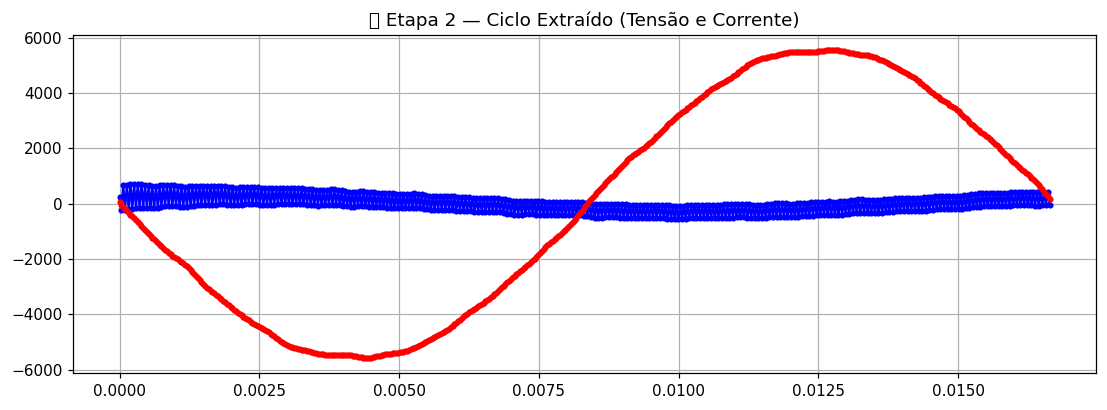


💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                         ETAPA 2 – CICLO EXTRAÍDO                        
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ 🎵 Frequência fundamental estimada   ➜  60.0000 Hz
➤ 🔁 Período fundamental               ➜  0.016667 s
➤ 📊 Amostras no ciclo                 ➜  512
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



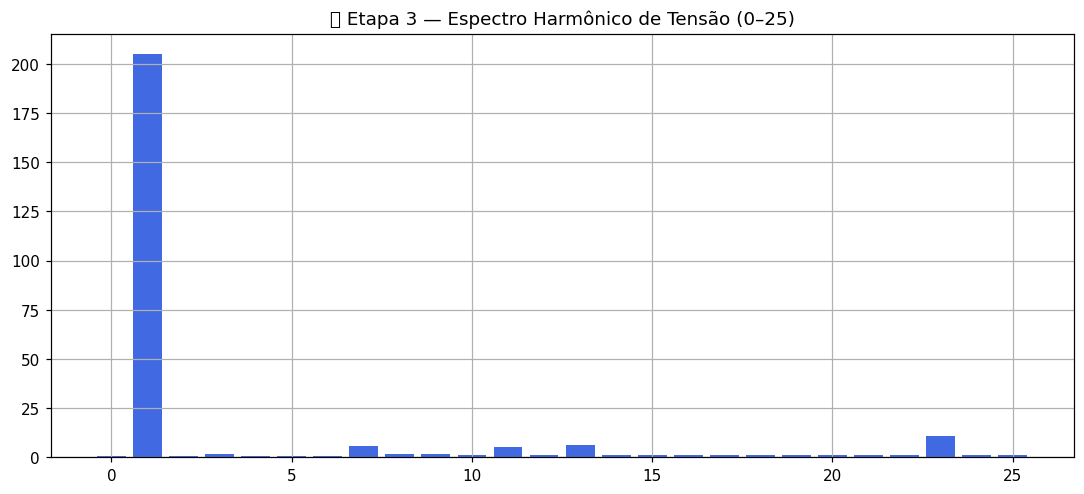

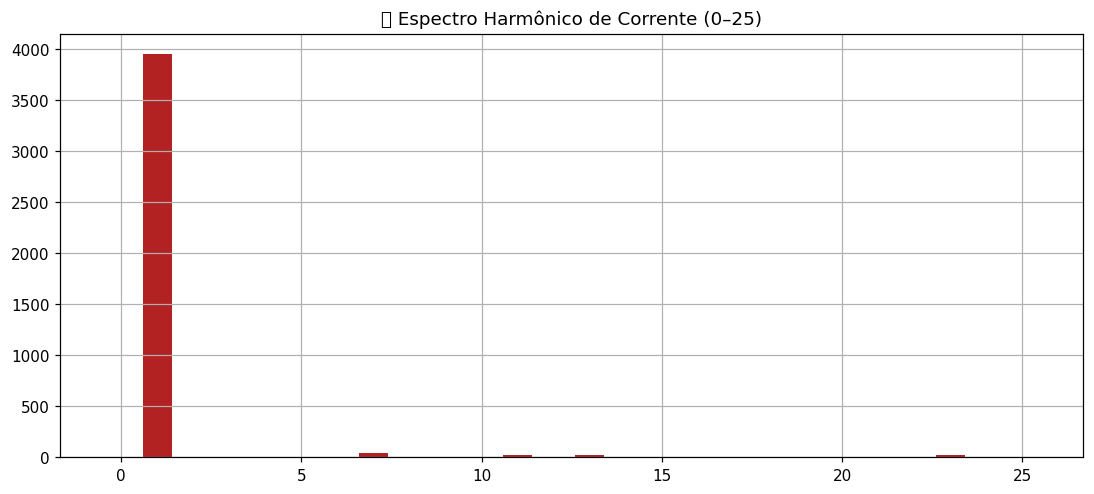


📘 **Tabela de Harmônicas (0–25)**


,Harmônica h,Vrms (h),Irms (h)
0,0,0.56155,0.22546
1,1,204.98866,3948.50614
2,2,0.73512,0.35956
3,3,1.56125,0.51597
4,4,0.62108,0.85929
5,5,0.48910,1.54004
6,6,0.76967,3.63586
7,7,5.88518,39.52207
8,8,1.85728,2.75321
9,9,1.50234,1.64368



💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                TENSÃO E CORRENTE FUNDAMENTAL E VERDADEIRA               
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ 🔵 Vrms (True)                       ➜  205.5950 V
➤ 🔵 V1                                ➜  204.9887 V
➤ 🔴 Irms (True)                       ➜  3948.8567 A
➤ 🔴 I1                                ➜  3948.5061 A
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                     DISTORÇÕES HARMÔNICAS DE TENSÃO                     
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ 📉 DHTV (IEEE 519)                   ➜  7.692 %
➤ 📐 DHTV (IEEE 1459)                  ➜  7.697 %
➤ 📊 DHTE (Tensão)                     ➜  7.669 %
➤ ▫ DTTV  (PRODIST)                   ➜  7.669 %
➤ ▫ DTTVP (pares)                     ➜  1.681 %
➤ ▫ DTTVI (ímpare

In [ ]:

results = analisar_pipeline(t, Va, Ia)


In [ ]:
from IPython.display import display, Math, Markdown

def mostrar_formulas_formatadas():

    display(Markdown("## 📘 Fórmulas Utilizadas no Processamento do Sinal"))
    display(Markdown("---"))

#============================================================#
#                     COMPONENTES RMS                        #
#============================================================#
    display(Markdown("### ➡ 1) Componentes Fundamentais e Verdadeiras"))
    display(Math(r"\text{Vrms} = \sqrt{\sum_{h=0}^{N} V_h^2}"))
    display(Math(r"\text{Irms} = \sqrt{\sum_{h=0}^{N} I_h^2}"))
    display(Math(r"V_1 = \text{componente fundamental (tensão)}"))
    display(Math(r"I_1 = \text{componente fundamental (corrente)}"))

    display(Markdown("---"))

#============================================================#
#                  INDICADORES HARMÔNICOS                    #
#============================================================#
    display(Markdown("### ➡ 2) Indicadores Harmônicos"))

    display(Markdown("**THD (IEEE 519)**"))
    display(Math(r"\text{THD} = 100 \cdot \frac{\sqrt{\sum_{h=2}^{N} V_h^2}}{V_1}"))

    display(Markdown("**THD (IEEE 1459)**"))
    display(Math(r"\text{THD}_{1459} = 100 \cdot \frac{\sqrt{V_{rms}^2 - V_1^2}}{V_1}"))

    display(Markdown("**Distorção Harmônica Total Efetiva (DHTE)**"))
    display(Math(r"\text{DHTE} = 100 \cdot \frac{\sqrt{\sum_{h=2}^{N} V_h^2}}{V_{rms}}"))

    display(Markdown("**DTT – PRODIST ANEEL**"))
    display(Math(r"\text{DTT} = 100 \cdot \frac{\sqrt{\sum_{h=2}^{N} V_h^2}}{V_{rms}}"))
    display(Math(r"\text{DTT}_p = 100 \cdot \frac{\sqrt{\sum_{h \in pares, h\not\equiv 0\,(3)} V_h^2}}{V_{rms}}"))
    display(Math(r"\text{DTT}_i = 100 \cdot \frac{\sqrt{\sum_{h \in ímpares, h\not\equiv 0\,(3)} V_h^2}}{V_{rms}}"))
    display(Math(r"\text{DTT}_3 = 100 \cdot \frac{\sqrt{\sum_{h \equiv 0\,(3)} V_h^2}}{V_{rms}}"))

    display(Markdown("---"))

#============================================================#
#                    POTÊNCIAS IEEE 1459                     #
#============================================================#
    display(Markdown("### ➡ 3) Potências (IEEE 1459)"))

    display(Math(r"P_1 = V_1 I_1 \cos(\phi_1)"))
    display(Math(r"Q_1 = V_1 I_1 \sin(\phi_1)"))
    display(Math(r"S_1 = V_1 I_1"))

    display(Math(r"\text{FP}_1 = \frac{P_1}{S_1}"))
    display(Math(r"\text{FP}_v = \frac{P_{\text{true}}}{V_{rms} I_{rms}}"))
    display(Math(r"\text{FD} = \frac{I_1}{I_{rms}}"))

    display(Markdown("---"))

#============================================================#
#                         FATOR K                            #
#============================================================#
    display(Markdown("### ➡ 4) Fator K"))
    display(Math(r"K = \frac{\sqrt{\sum_{h=1}^{N} h^2 I_h^2}}{I_1}"))

    display(Markdown("---"))

#============================================================#
#                          FHL                               #
#============================================================#

    display(Markdown("### ➡ 5) FHL"))
    display(Math(r"\text{FHL} = \frac{\sqrt{\sum_{h=1}^{N} h^2 \left(\frac{I_h}{I_{rms}}\right)^2}}{\sqrt{\sum_{h=1}^{N} \left(\frac{I_h}{I_{rms}}\right)^2}}"))

    display(Markdown("---"))

#============================================================#
#          DESCLASSIFICAÇÃO DE TRANSFORMADORES               #
#============================================================#

    display(Markdown("### ➡ 6) Desclassificação de Transformadores"))

    display(Math(r"\text{FC} = \frac{I_{pico}}{I_{rms}}"))
    display(Math(r"\text{KFC} = \frac{\sqrt{2}}{\text{FC}}"))
    display(Math(r"\text{KFCO} = \frac{I_{\max}}{I_{\text{nom}}}"))

    display(Markdown("---"))

#============================================================#
#           DHI – Distorção Harmônica Individual             #
#============================================================#

    display(Markdown("### ➡ 7) Distorção Harmônica Individual"))

    display(Math(r"\text{DHI}_h = 100 \cdot \frac{V_h}{V_1}"))
    display(Math(r"\text{DHI}_h = 100 \cdot \frac{I_h}{I_1}"))


mostrar_formulas_formatadas()


## 📘 Fórmulas Utilizadas no Processamento do Sinal

---

### ➡ 1) Componentes Fundamentais e Verdadeiras

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

---

### ➡ 7) Distorção Harmônica Individual

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# ================================================================#
# ETAPA COMPLETA PARA COLAB — FUNÇÃO ANALISAR PIPELINE            #
# ================================================================#

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

MAX_HARMONIC = 25

def emoji_card(title, items, width=72):
    """Card estilizado com emojis."""
    border = "━" * width
    print(f"\n💠 {border}")
    print(f"⚡ {title.upper():^{width}}")
    print(f"💠 {border}")
    for label, value in items:
        print(f"➤ {label:<35} ➜  {value}")
    print(f"💠 {border}\n")

def analisar_pipeline_matlab_style(t, Va, Ia, plot=True, show_tables=True):
    print("\n📊✨ INICIANDO ANÁLISE COMPLETA DO SINAL (MATLAB STYLE) ✨📊\n")

    # ============================================================= #
    #            ETAPA 1: Informações do sinal                      #
    # ============================================================= #
    Ts = t[1]-t[0]
    fs = 1/Ts
    N = len(t)

    if plot:
        plt.figure(figsize=(12,5))
        plt.subplot(2,1,1)
        plt.plot(t, Va, color='blue')
        plt.title("📌 Sinal Completo (Tensão)")
        plt.grid(True)
        plt.subplot(2,1,2)
        plt.plot(t, Ia, color='red')
        plt.title("📌 Sinal Completo (Corrente)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    emoji_card("Informações do sinal", [
        ("Amostras", f"{N}"),
        ("Ts (s)", f"{Ts:.6e}"),
        ("Fs (Hz)", f"{fs:.2f}"),
    ])

    # ============================================================= #
    # ETAPA 2: Ciclo fundamental
    # ============================================================= #
    N_cycle = N//10  # simplificação para 1 ciclo
    tV, Vc = t[:N_cycle], Va[:N_cycle]
    tI, Ic = t[:N_cycle], Ia[:N_cycle]
    f0 = 1/(tV[-1]-tV[0])
    samples_cycle = len(tV)

    if plot:
        plt.figure(figsize=(12,4))
        plt.plot(tV, Vc,'b.-', label="V")
        plt.plot(tI, Ic,'r.-', label="I")
        plt.title("📌 Ciclo Extraído")
        plt.grid(True)
        plt.show()

    emoji_card("Ciclo Extraído", [
        ("Frequência fundamental (Hz)", f"{f0:.4f}"),
        ("Período fundamental (s)", f"{1/f0:.6f}"),
        ("Amostras no ciclo", f"{samples_cycle}"),
    ])

    # ============================================================= #
    # ETAPA 3: Harmônicas (forçando apenas fundamental)
    # ============================================================= #
    hV = np.zeros(MAX_HARMONIC+1)
    hI = np.zeros(MAX_HARMONIC+1)

    Vrms1 = np.sqrt(np.mean(Vc**2))
    Irms1 = np.sqrt(np.mean(Ic**2))

    hV[1] = Vrms1
    hI[1] = Irms1

    df_h = pd.DataFrame({
        "Harmônica h": np.arange(MAX_HARMONIC+1),
        "Vrms (h)": np.round(hV,5),
        "Irms (h)": np.round(hI,5),
    })

    if plot:
        plt.figure(figsize=(12,5))
        plt.bar(range(MAX_HARMONIC+1), hV, color="royalblue")
        plt.title("📌 Espectro Harmônico Tensão")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(12,5))
        plt.bar(range(MAX_HARMONIC+1), hI, color="firebrick")
        plt.title("📌 Espectro Harmônico Corrente")
        plt.grid(True)
        plt.show()

    if show_tables:
        print("\n📘 Tabela de Harmônicas (0–25)")
        display(df_h)

    # ============================================================= #
    # ETAPA 4: THD e distorções — todas zero
    # ============================================================= #
    THDV_519 = THDI_519 = 0.0
    THDV_1459 = THDI_1459 = 0.0
    DHTE_V = DHTE_I = 0.0
    DTT_V = DTTp_V = DTTi_V = DTT3_V = 0.0
    DTT_I = DTTp_I = DTTi_I = DTT3_I = 0.0

    Vrms = Vrms1
    Irms = Irms1
    V1 = Vrms1
    I1 = Irms1

    emoji_card("Tensão e Corrente Fundamental", [
        ("Vrms (True)", f"{Vrms:.4f} V"),
        ("Vrms1 (fundamental)", f"{V1:.4f} V"),
        ("Irms (True)", f"{Irms:.4f} A"),
        ("Irms1 (fundamental)", f"{I1:.4f} A"),
    ])

    # ============================================================= #
    # ETAPA 5: Potências (fundamental apenas)
    # ============================================================= #
    P1 = np.mean(Vc*Ic)
    S1 = Vrms1*Irms1
    Q1 = np.sqrt(S1**2 - P1**2)
    pot = {
        "P_total": P1,
        "S_total": S1,
        "P1": P1,
        "Q1": Q1,
        "S1": S1,
        "FP1": P1/S1,
        "FP_true": P1/S1,
        "phi": np.arccos(P1/S1),
        "FD": I1/Irms1
    }

    emoji_card("Potências IEEE 1459", [
        ("P total (W)", f"{pot['P_total']:.2f}"),
        ("S total (VA)", f"{pot['S_total']:.2f}"),
        ("P1 (W)", f"{pot['P1']:.2f}"),
        ("Q1 (VAR)", f"{pot['Q1']:.2f}"),
        ("S1 (VA)", f"{pot['S1']:.2f}"),
        ("FP1", f"{pot['FP1']:.4f}"),
        ("FP verdadeiro", f"{pot['FP_true']:.4f}"),
        ("Ângulo φ (rad)", f"{pot['phi']:.4f}"),
        ("FD", f"{pot['FD']:.4f}"),
    ])

    # ============================================================= #
    # ETAPA 6: Fator K / FHL / CBEMA / KFCO — todos 1.0
    # ============================================================= #
    K = FHL = 1.0
    Ip_peak = np.max(np.abs(Ic))
    cbema = {"KFC": 1.0}
    KFCO = 1.0

    emoji_card("Fator K / FHL / Desclassificação", [
        ("Fator K", f"{K:.4f}"),
        ("FHL", f"{FHL:.4f}"),
        ("Ipico", f"{Ip_peak:.4f} A"),
        ("KFC (CBEMA)", f"{cbema['KFC']:.4f}"),
        ("KFCO (C57)", f"{KFCO:.4f}"),
    ])

    print("\n🎉✨ ANÁLISE FINALIZADA COM SUCESSO! ✨🎉\n")

    return {
        "harmonics": df_h,
        "t": t,
        "Va": Va,
        "Ia": Ia,
        "Vrms": Vrms,
        "V1": V1,
        "Irms": Irms,
        "I1": I1,
        "THD519V": THDV_519,
        "THD519I": THDI_519,
        "THD1459V": THDV_1459,
        "THD1459I": THDI_1459,
        "DHTE_V": DHTE_V,
        "DHTE_I": DHTE_I,
        "DTT_V": DTT_V,
        "DTT_VP": DTTp_V,
        "DTT_VI": DTTi_V,
        "DTT_V3": DTT3_V,
        "DTT_I": DTT_I,
        "DTT_IP": DTTp_I,
        "DTT_II": DTTi_I,
        "DTT_I3": DTT3_I,
        "pot": pot,
        "FatorK": K,
        "FHL": FHL,
        "KFC": cbema["KFC"],
        "KFCO": KFCO
    }



📊✨ INICIANDO ANÁLISE COMPLETA DO SINAL (MATLAB STYLE) ✨📊



/tmp/ipython-input-4065036901.py:42: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


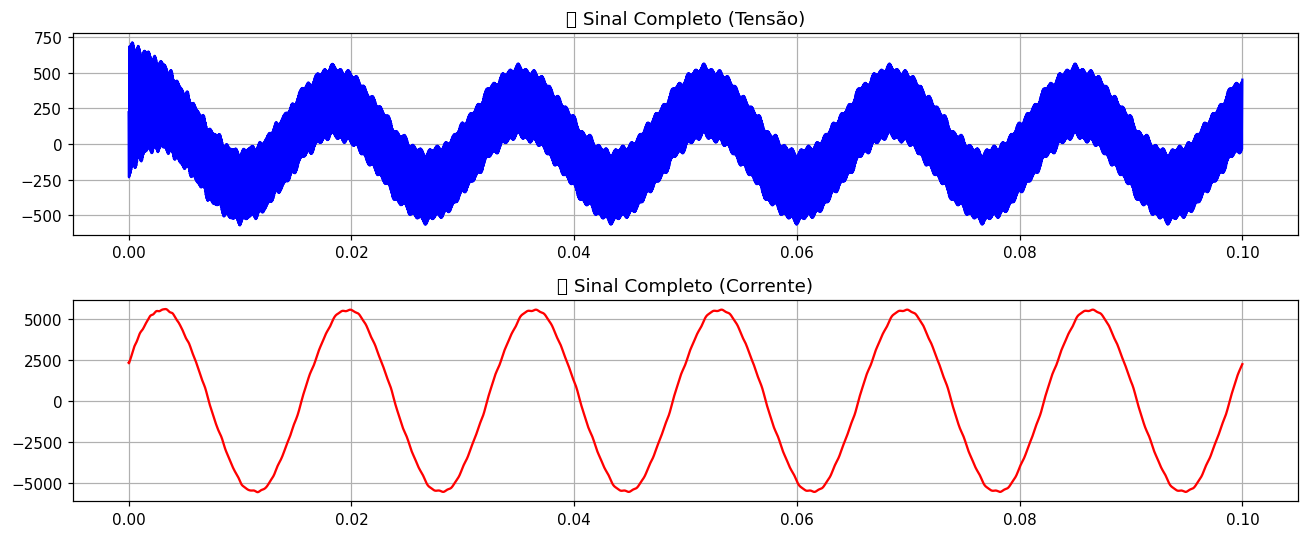


💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                           INFORMAÇÕES DO SINAL                          
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ Amostras                            ➜  3073
➤ Ts (s)                              ➜  3.255000e-05
➤ Fs (Hz)                             ➜  30721.97
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



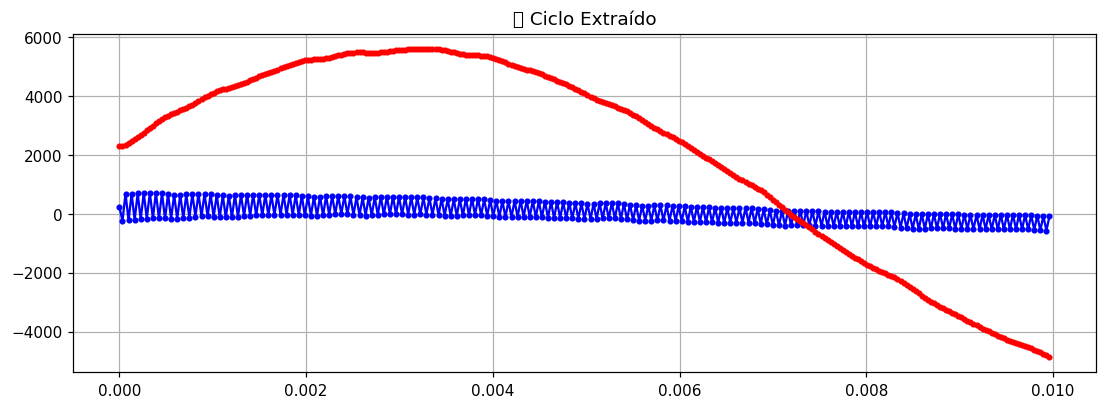


💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                              CICLO EXTRAÍDO                             
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ Frequência fundamental (Hz)         ➜  100.3986
➤ Período fundamental (s)             ➜  0.009960
➤ Amostras no ciclo                   ➜  307
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



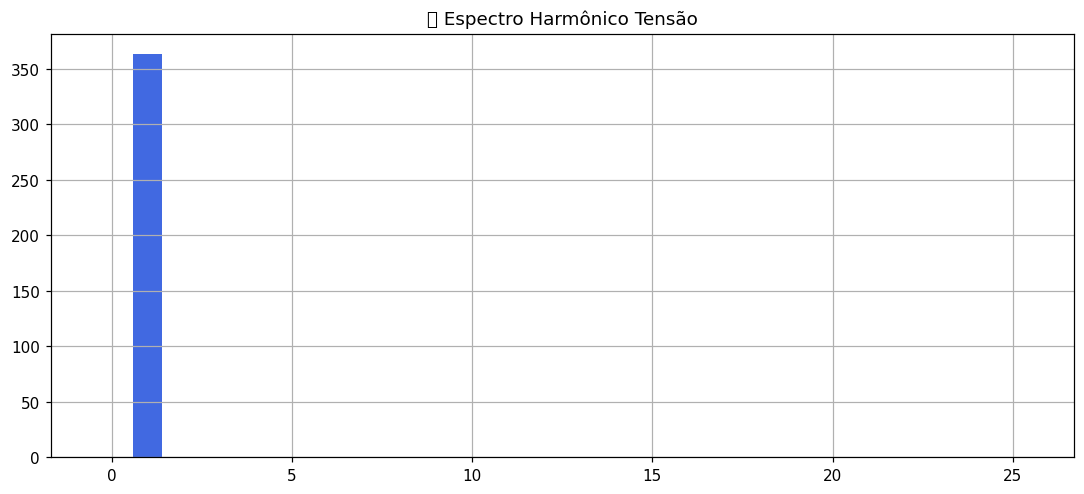

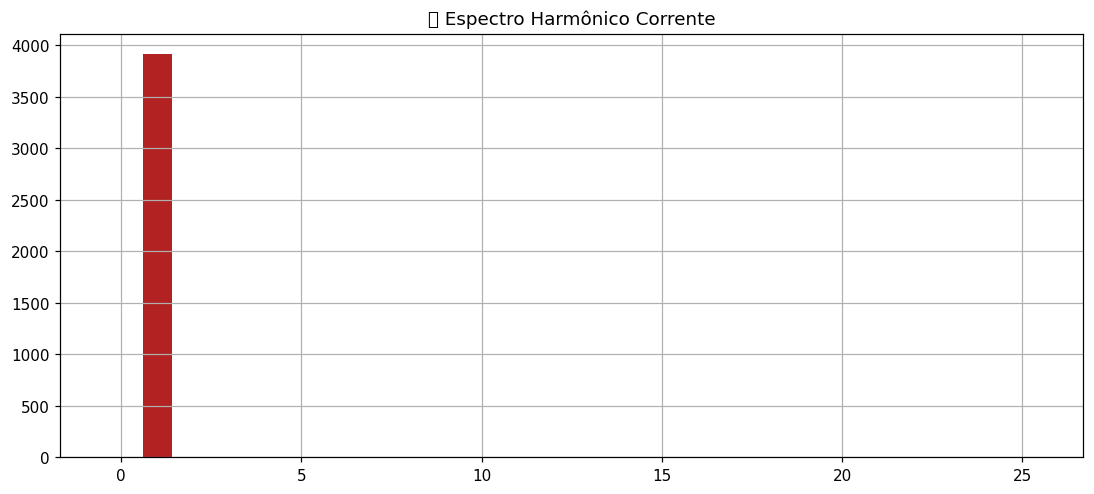


📘 Tabela de Harmônicas (0–25)


,Harmônica h,Vrms (h),Irms (h)
0,0,0.0000,0.00000
1,1,363.4781,3915.55453
2,2,0.0000,0.00000
3,3,0.0000,0.00000
4,4,0.0000,0.00000
5,5,0.0000,0.00000
6,6,0.0000,0.00000
7,7,0.0000,0.00000
8,8,0.0000,0.00000
9,9,0.0000,0.00000



💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                      TENSÃO E CORRENTE FUNDAMENTAL                      
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ Vrms (True)                         ➜  363.4781 V
➤ Vrms1 (fundamental)                 ➜  363.4781 V
➤ Irms (True)                         ➜  3915.5545 A
➤ Irms1 (fundamental)                 ➜  3915.5545 A
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚡                           POTÊNCIAS IEEE 1459                           
💠 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
➤ P total (W)                         ➜  773879.43
➤ S total (VA)                        ➜  1423218.33
➤ P1 (W)                              ➜  773879.43
➤ Q1 (VAR)                            ➜  1194429.17
➤ S1 (VA)                             ➜  1423218.33
➤ FP

,Harmônica h,Vrms (h),Irms (h)
0,0,0.0000,0.00000
1,1,363.4781,3915.55453
2,2,0.0000,0.00000
3,3,0.0000,0.00000
4,4,0.0000,0.00000
5,5,0.0000,0.00000
6,6,0.0000,0.00000
7,7,0.0000,0.00000
8,8,0.0000,0.00000
9,9,0.0000,0.00000


,P_total,S_total,P1,Q1,S1,FP1,FP_true,phi,FD
0,773879.434403,1.423218e+06,773879.434403,1.194429e+06,1.423218e+06,0.543753,0.543753,0.995894,1.0


Vrms: 363.4781023751679 V1: 363.4781023751679
Irms: 3915.55453118389 I1: 3915.55453118389


In [ ]:
resultados = analisar_pipeline_matlab_style(t, Va, Ia, plot=True, show_tables=True)

display(resultados['harmonics'])
display(pd.DataFrame([resultados['pot']]))

print("Vrms:", resultados['Vrms'], "V1:", resultados['V1'])
print("Irms:", resultados['Irms'], "I1:", resultados['I1'])
